# 社會網絡分析與地理應用 第八週作業(搶救期中考)

資訊工程學系 三年級 吳佳泰 S1254059

> 期中考第2、6、7，這三題的得分打9折，如果該題打9折後的分數比原本高，可取代該題原本的成績。

## 試題提供的檔案為某系所 100 位學生的修課紀錄，假設兩位學生共同修習某一門課可代表兩位學生之間存在接觸關係，並且有可能因此造成傳染病的傳播，請回答下列問題：

In [10]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from operator import itemgetter

In [2]:
df = pd.read_csv("class_data.csv")
n = df.values
df

,Student,Course_1,Course_2,Course_3,Course_4,Course_5,Course_6,Course_7,Course_8,Course_9,...,Course_21,Course_22,Course_23,Course_24,Course_25,Course_26,Course_27,Course_28,Course_29,Course_30
0,Student_1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,Student_2,1,0,0,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,Student_3,1,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,Student_4,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,Student_5,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Student_96,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
96,Student_97,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
97,Student_98,0,0,1,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
98,Student_99,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1


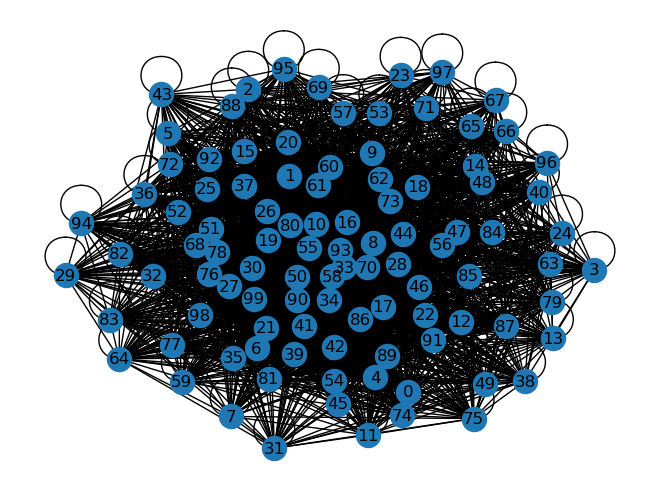

In [3]:
df.drop("Student", axis=1, inplace=True)
n = df.values@df.values.T
g = nx.from_numpy_array(n)
nx.draw(g, with_labels=True)

### 2. 根據經驗，在傳染病疫情中，大多數民眾只會傳播疾病給予周遭的人；只有少數的超級傳播者具有異常大量與他人接觸的頻率，進而造成大規模擴散。請問在學生網絡中，是否存在此現象？（20%）

> Ans：否，根據 Degree Centrality 分析結果，學生網絡的平均中心性為0.57，標準差為0.14，顯示節點間連結程度差異有限。最高值為0.91，與平均值相比僅約1.5倍，未出現顯著高於整體的節點。此外，多數節點的中心性分佈集中於中高區間，未呈現明顯的長尾分佈。綜合上述結果，可推論該學生網絡屬於較為均勻且密集的結構，不存在典型的超級傳播者現象

Average : 0.572929292929293
Standard Deviation : 0.13998615233160636
Maximum : 0.9090909090909092
Minimum :  0.36363636363636365
TOP 5 Student Average : 0.8767676767676769


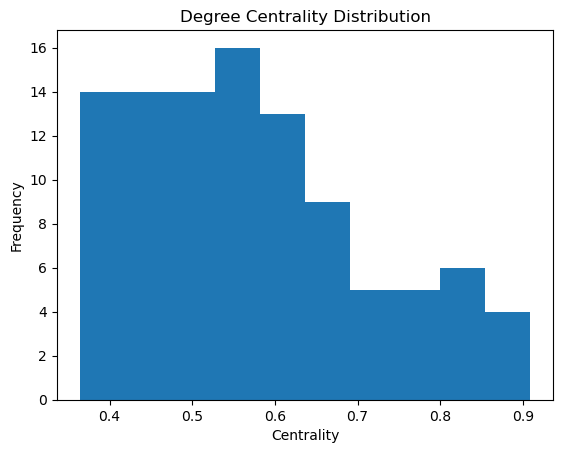

In [16]:
dict1 = dict(sorted(nx.degree_centrality(g).items(),key=itemgetter(1), reverse=True))

print("Average :", np.mean(list(dict1.values())))
print("Standard Deviation :", np.std(list(dict1.values())))
print("Maximum :", max(dict1.values()))
print("Minimum : ", min(dict1.values()))
print("TOP 5 Student Average :", np.mean(list(dict1.values())[:5]))

values = list(dict1.values())
plt.hist(values, bins=10)
plt.title("Degree Centrality Distribution")
plt.xlabel("Centrality")
plt.ylabel("Frequency")
plt.show()

### 6. 為了擴大考量可能的潛在接觸傳播，針對接觸網絡進行分群分析，能夠同時匡列確診者與高風險的學生。在假設編號 11 的學生確診的情況下，請列出應該密切關注的高風險學生名單。(10%)

> Ans：利用 Louvain Method 找出分群，並將目標鎖定於編號 11 的學生所在的分群，發現與編號 11 的學生接觸最多次的學生為 9 號 (Python 編號從 0 開始)

In [48]:
community = nx.community.louvain_communities(g, seed=42) #fixing the seed to ensure consistent output
community_11 = None
list1 = []

for i in range(len(community)):
    print("Community", i+1, ":", sorted(community[i]))

    if (10 in community[i]):
        community_11 = community[i]

print("\nCommunity with 11 :", community_11)

for i in community_11:
    list1.append([i, n[10][i]])

list1.sort(key=lambda x: x[1], reverse=True)

print("\nStudent", "Contact with 11 times", sep="\t")

for i in list1:
    print(i[0], i[1], sep="\t")

Community 1 : [1, 2, 15, 18, 19, 20, 26, 27, 30, 36, 43, 47, 52, 64, 68, 69, 72, 77, 82, 88, 93, 97, 98]
Community 2 : [5, 7, 8, 10, 14, 23, 25, 32, 40, 48, 55, 57, 61, 62, 65, 71, 76, 79, 85, 90, 95]
Community 3 : [29, 37, 50, 56, 78, 84]
Community 4 : [3, 13, 53, 66, 96]
Community 5 : [11, 24, 28, 34, 35, 38, 42, 44, 49, 54, 63, 75, 87, 91]
Community 6 : [0, 4, 6, 12, 17, 21, 22, 31, 33, 39, 41, 45, 46, 58, 59, 70, 74, 81, 86, 89]
Community 7 : [9, 16, 51, 60, 67, 73, 80, 83, 92, 94, 99]

Community with 11 : {65, 5, 7, 8, 71, 10, 76, 14, 79, 85, 23, 25, 90, 95, 32, 40, 48, 55, 57, 61, 62}

Student	Contact with 11 times
10	9
8	5
55	4
61	4
32	3
57	3
62	3
65	2
5	2
76	2
85	2
23	2
40	2
48	2
7	1
71	1
14	1
25	1
90	1
95	1
79	0


### 7. 呈上題，如果想要在每一個分群裡面都挑選一位同學進行防疫隔離，請問應該挑選哪幾位同學？挑選的理由為何？（10%）

> Ans：編號 94、9、51、54、29、71、81 (Python 編號從 0 開始)，藉由找出每個群體內 Betweenness Centrality 最高的人，以最大化切斷社群間與社群內的傳播路徑

In [47]:
betweenness = nx.betweenness_centrality(g)

list1 = []

for i in community:
    temp = max(i, key=lambda x: betweenness[x])
    list1.append(temp)

list1

[93, 8, 50, 53, 28, 70, 80]